# Artificial Structural Conditioning Analysis

This notebook is intentionally thin: dataset loading, graph diagnostics, and plotting live in reusable package helpers. It checks whether conditioning on a structural statistic steers generated artificial graphs toward that statistic.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
from IPython.display import display

from conditional_node_field_graph_generator.notebooks import configure_notebook
from conditional_node_field_graph_generator.extensions.demo.artificial import (
    build_artificial_plotter,
    find_latest_artificial_dataset_config,
    load_latest_artificial_graph_generator,
    generate_artificial_dataset,
)
from conditional_node_field_graph_generator.extensions.demo.artificial_conditioning import (
    histogram_tables,
    plot_conditioning_vector_test,
    run_conditioning_vector_test,
)

globals().update(configure_notebook(require_nsppk=True, print_torch=True))

PyTorch version: 2.13.0
CUDA available: False


Loaded graph generator: artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl
/Users/f.costa/Code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.9.0 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.9.0 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dataset: artificial-cycle-path-star-n50000-c3-8-p2-r3x1-na3.yaml (50000 graphs)
Generator: artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl


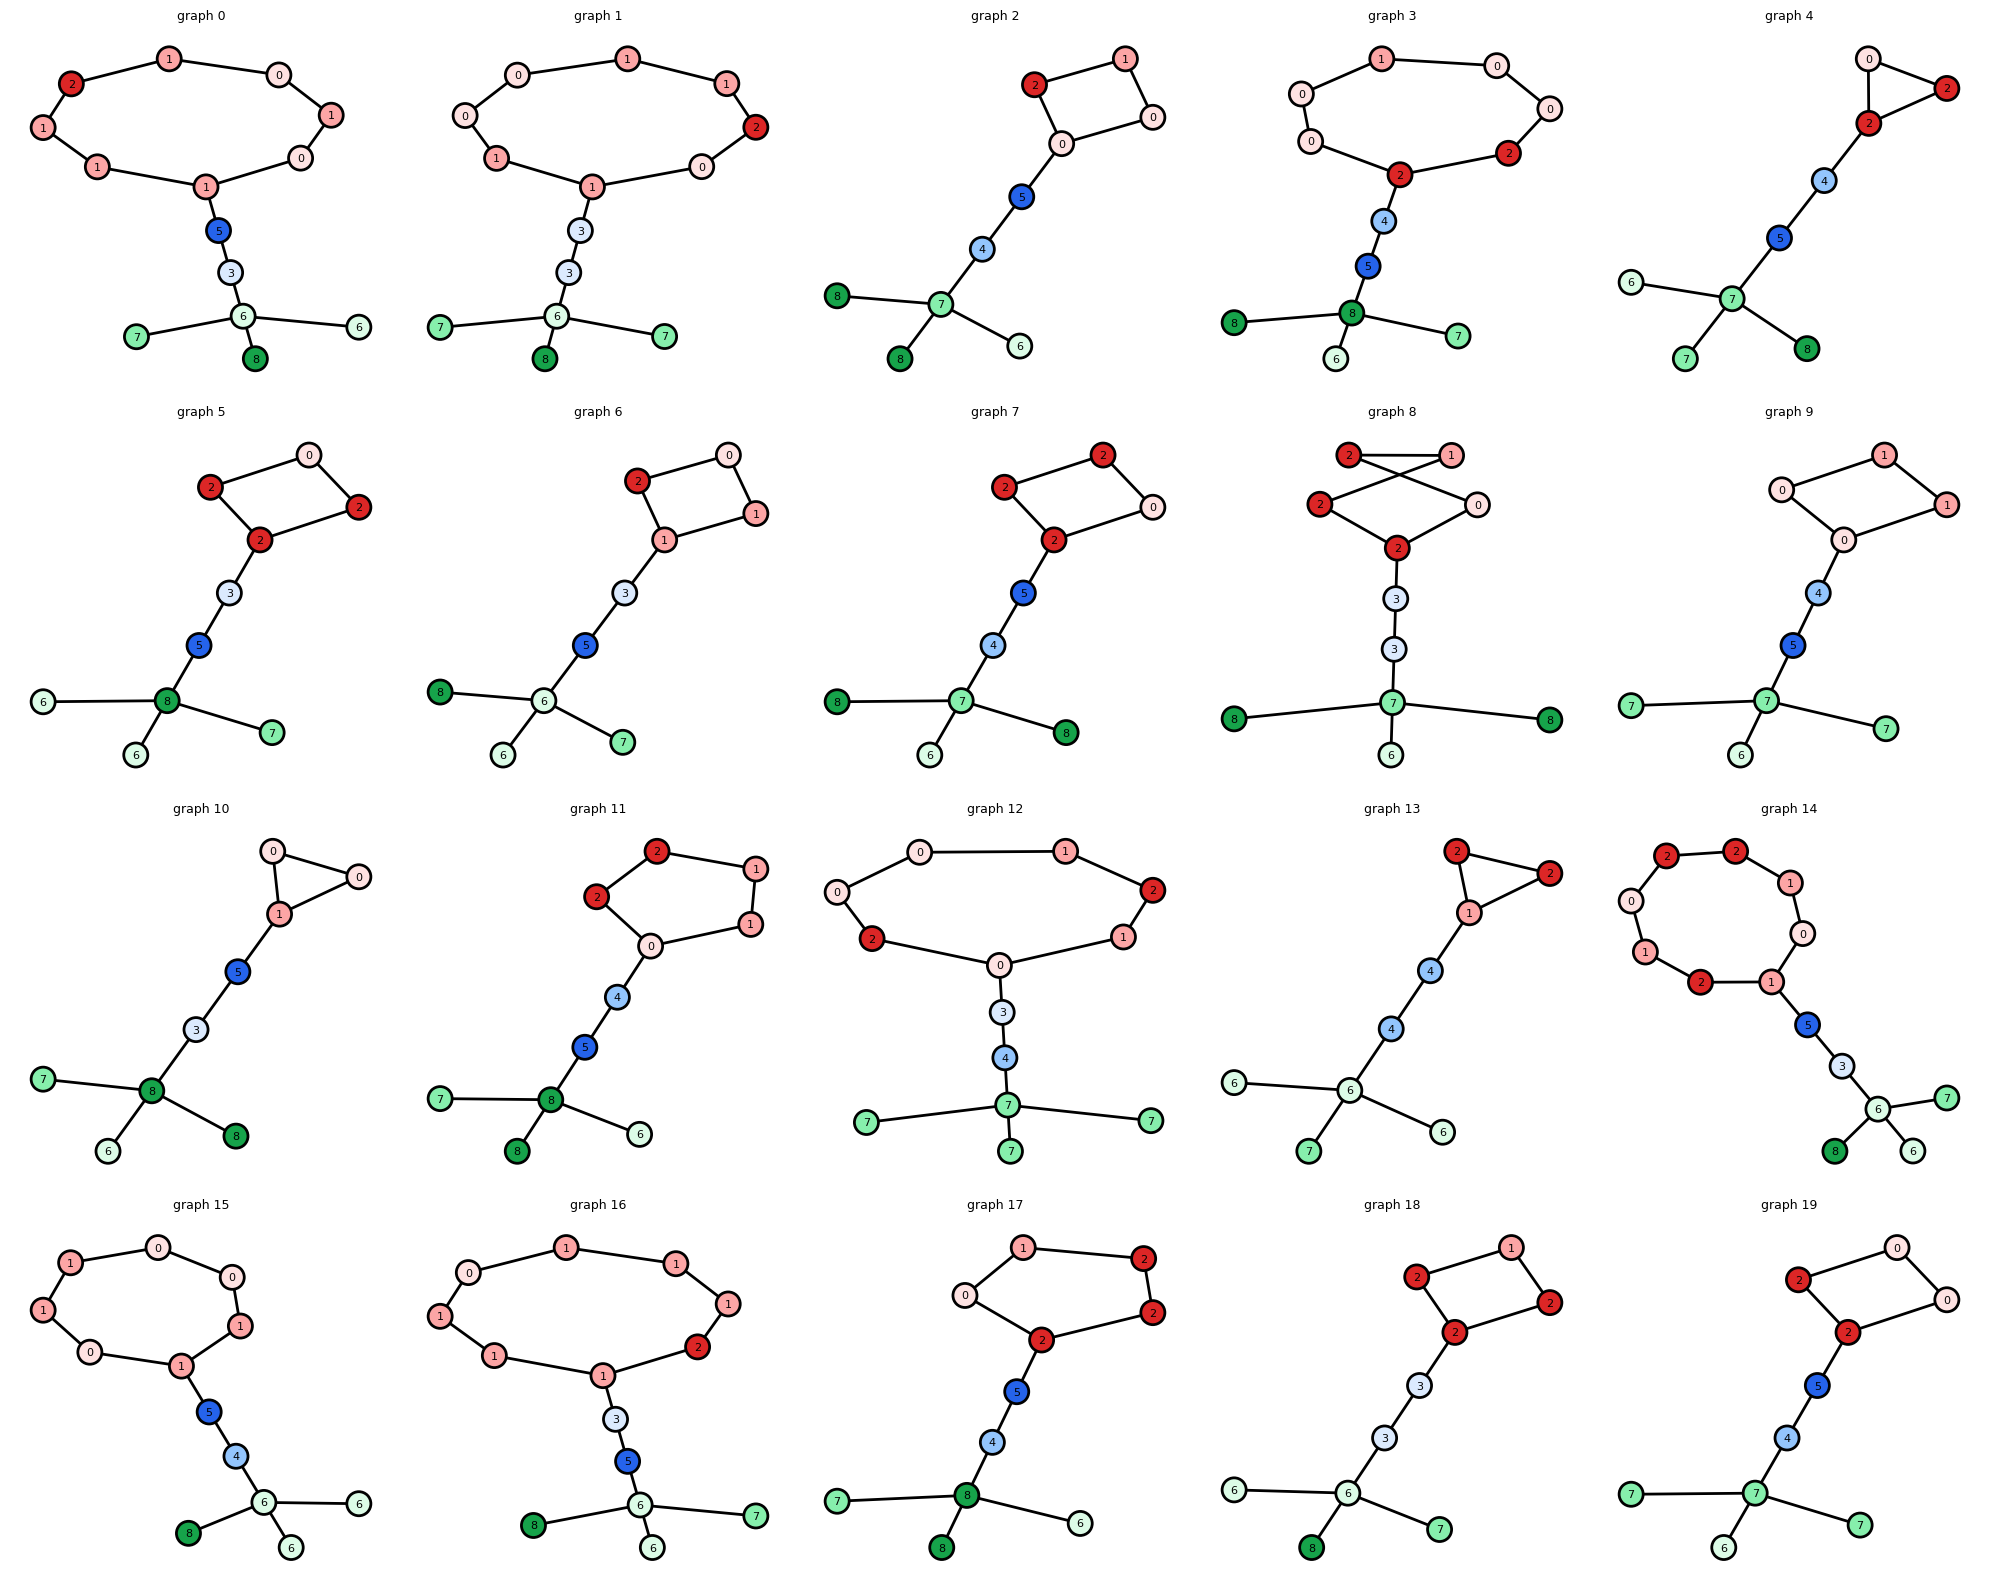

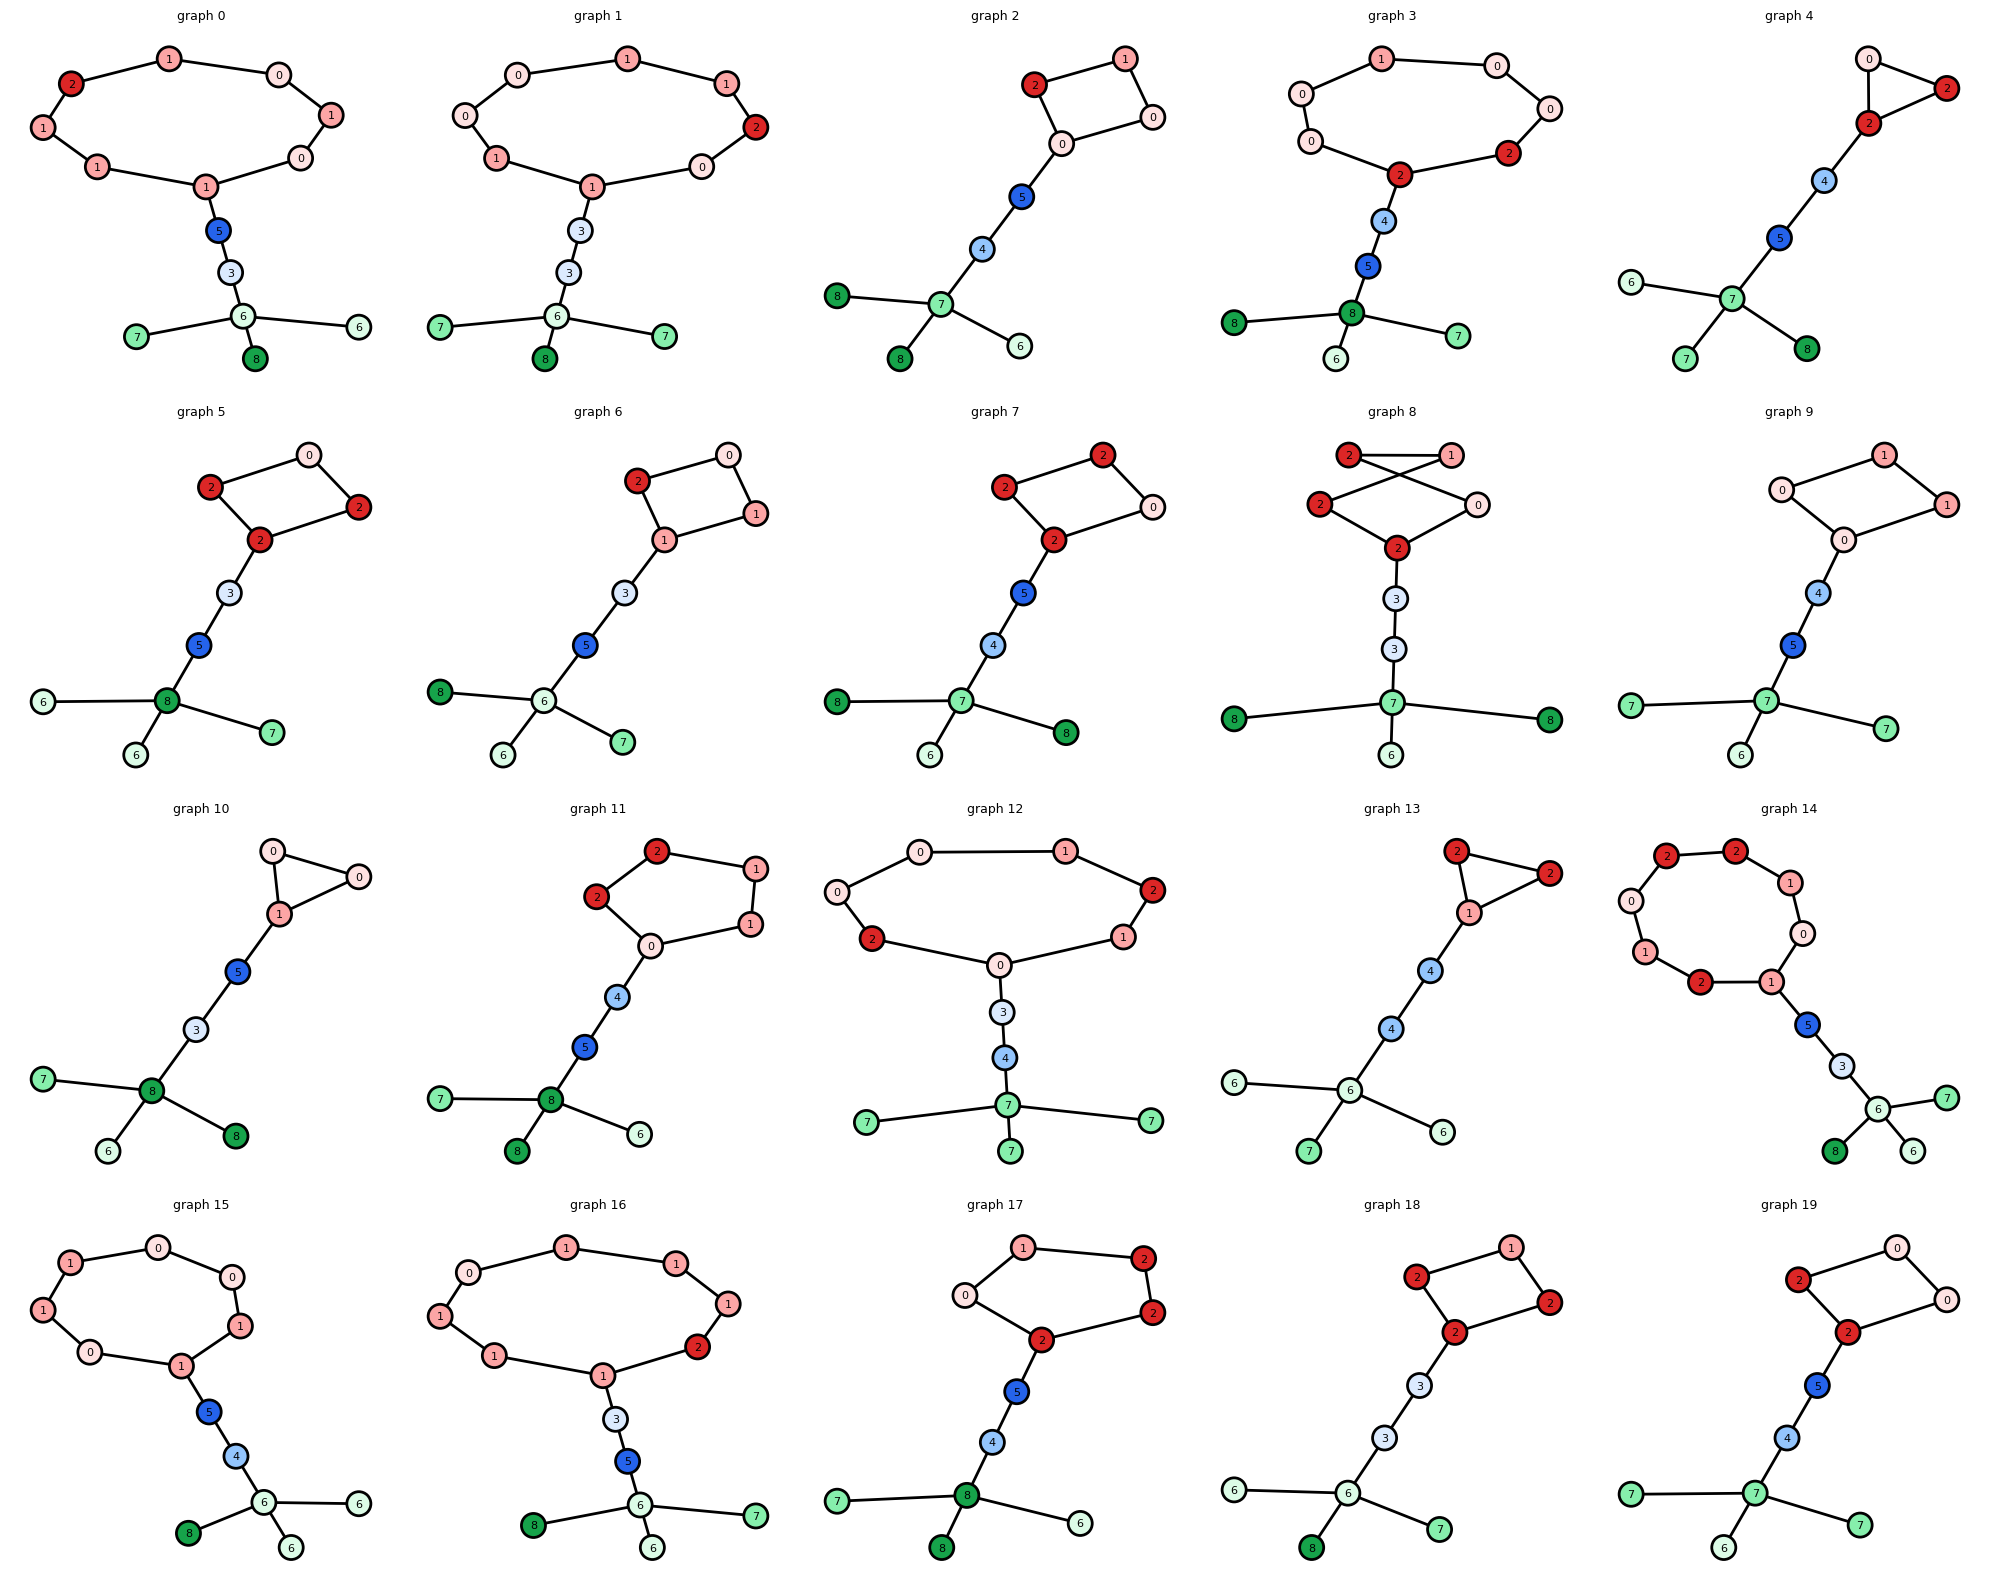

In [2]:
dataset_config_path = find_latest_artificial_dataset_config(REPO_ROOT / 'notebooks')
graphs, _ = generate_artificial_dataset(load_from_file=dataset_config_path, save_config=False)
graph_generator, generator_path = load_latest_artificial_graph_generator()
plotter = build_artificial_plotter()

print(f'Dataset: {dataset_config_path.name} ({len(graphs)} graphs)')
print(f'Generator: {Path(generator_path).name}')
plotter(graphs[:20], n_cols=min(5, len(graphs[:20])), titles=[f'graph {i}' for i in range(len(graphs[:20]))])

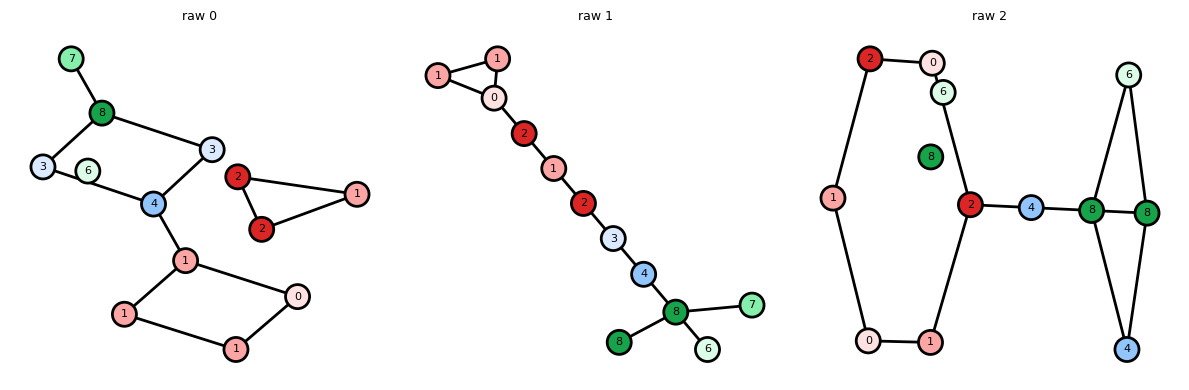

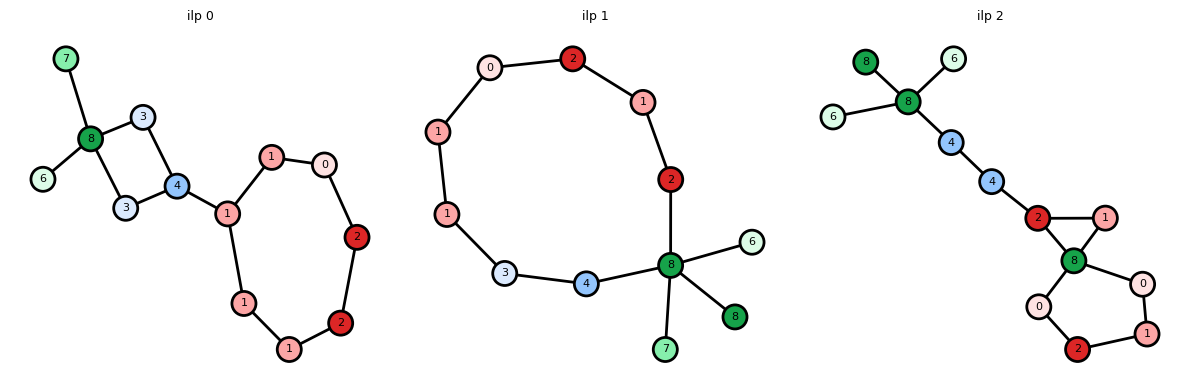

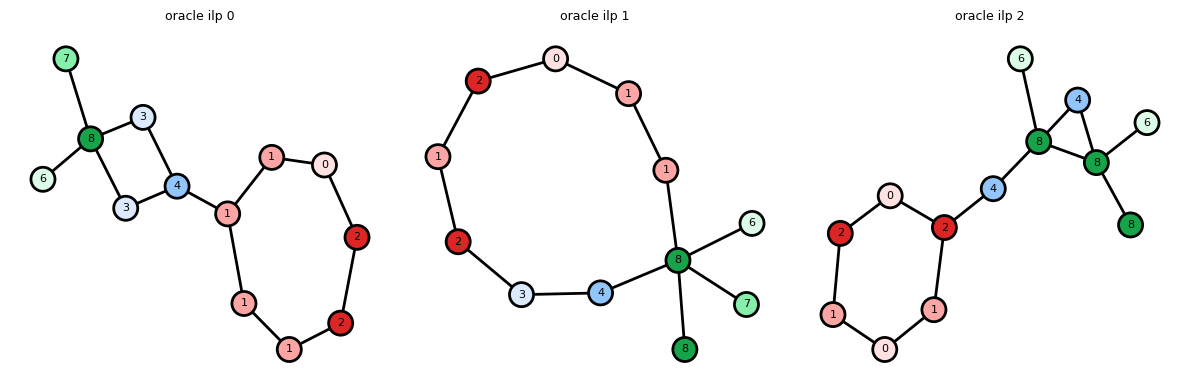

In [3]:
sample_variants = graph_generator.sample(3, return_decode_stages=True)
for variant_key, title_prefix in (('raw', 'raw'), ('ilp', 'ilp'), ('oracle', 'oracle ilp')):
    variant_samples = sample_variants[variant_key]
    plotter(
        variant_samples,
        n_cols=len(variant_samples),
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

## Conditioning test

Change `experiment_type` to `cycle_count`, `cycle_size`, `ray_count`, or `ray_size` to probe another structural statistic.

,conditioning_value,n_generated,valid_rate,generated_median,generated_q25,generated_q75,generated_mean,generated_std
0,2,32,1.0,2.0,2.0,2.0,2.0625,0.242061


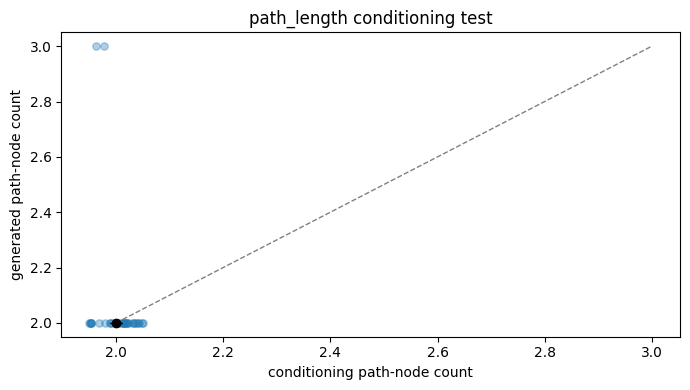

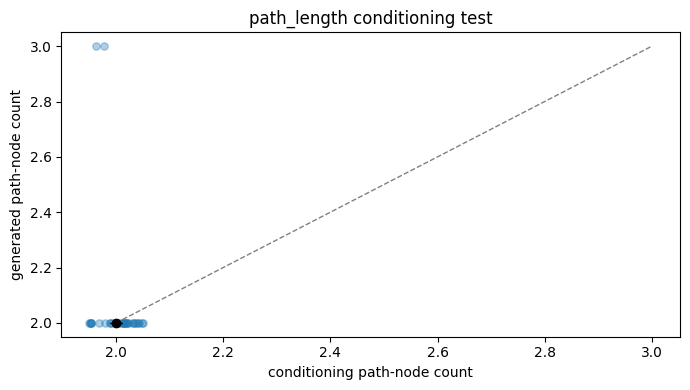

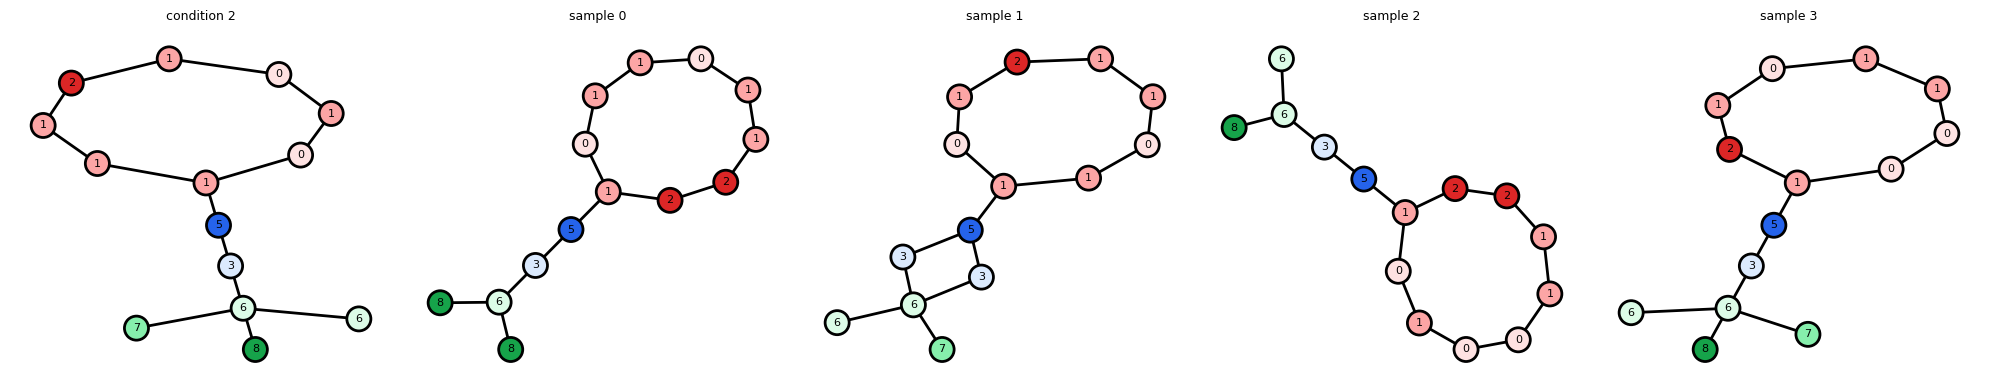

In [4]:
result = run_conditioning_vector_test(
    graphs,
    graph_generator,
    experiment_type='path_length',
    samples_per_conditioning_graph=32,
    apply_feasibility_filtering=False,
)

display(result['summary_df'])
plot_conditioning_vector_test(result, plotter, examples_per_condition=4)

In [5]:
condition_index = min(2, len(result['conditioning_graphs']) - 1)
label_table, degree_table = histogram_tables(
    result['conditioning_graphs'][condition_index],
    result['generated_by_graph'][condition_index],
)
display(label_table)
display(degree_table)

,label,conditioning_count,mean_generated_count,std_generated_count,mean_abs_error
0,0,2,2.46875,0.499022,0.46875
1,1,5,4.65625,0.642718,0.34375
2,2,1,1.25000,0.433013,0.25000
3,3,1,1.00000,0.250000,0.00000
4,5,1,1.06250,0.242061,0.06250
5,6,2,1.53125,0.558143,0.46875
6,7,1,0.84375,0.617929,0.15625
7,8,1,1.18750,0.634306,0.18750


,degree,conditioning_count,mean_generated_count,std_generated_count,mean_abs_error
0,1,3,2.6875,0.526634,0.3125
1,2,9,9.1875,0.768013,0.1875
2,3,1,1.3750,0.599479,0.3750
3,4,1,0.7500,0.433013,0.2500
